 # 8. The Principal Axis Theorem

In [1]:
from collections import Counter
from spb.graphics import (
    arrow_2d,
    graphics,
    implicit_2d,
    line
)
from spb.defaults import cfg
from sympy import (
    Eq,
    eye,
    Idx,
    IndexedBase,
    Matrix,
    MatrixSymbol,
    shape,
    Sum,
    Symbol,
    symbols
)

cfg['matplotlib']['show_minor_grid'] = True

In [2]:
a, b, x, y = symbols('a, b, x, y')

eq_ellipse = Eq(((x**2)/(a**2)) + ((y**2)/b**2), 1)
eq_ellipse

Eq(y**2/b**2 + x**2/a**2, 1)

In [3]:
eq_hyperbola = Eq(((x**2)/(a**2)) - ((y**2)/b**2), 1)
eq_hyperbola

Eq(-y**2/b**2 + x**2/a**2, 1)

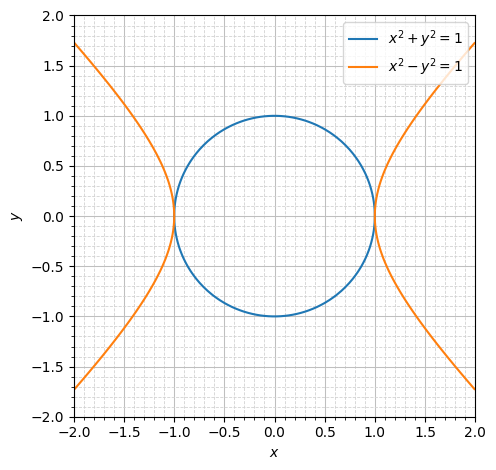

In [4]:
loci_subs = {a: 1, b: 1}

graphics(
    implicit_2d(eq_ellipse.subs(loci_subs), (x, -2, 2), (y, -2, 2)),
    implicit_2d(eq_hyperbola.subs(loci_subs), (x, -2, 2), (y, -2, 2)),
    aspect='equal'
)

In [5]:
c = Symbol('c')

quad_eq = a*x**2 + 2*b*x*y + c*y**2
eq_quadratic = Eq(quad_eq, 1)
eq_quadratic

Eq(a*x**2 + 2*b*x*y + c*y**2, 1)

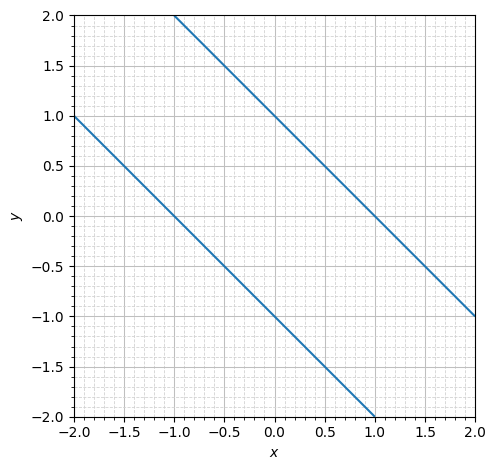

In [6]:
quad_subs = loci_subs | {c: 1}

graphics(
    implicit_2d(eq_quadratic.subs(quad_subs), (x, -2, 2), (y, -2, 2)),
    aspect='equal'
)

In [7]:
A = Matrix([[a, b], [b, c]])
xy = Matrix([x, y])

matrix_eq = xy.T*A*xy
eq_matrix = Eq(*matrix_eq, 1, evaluate=False)
eq_matrix

Eq(x*(a*x + b*y) + y*(b*x + c*y), 1)

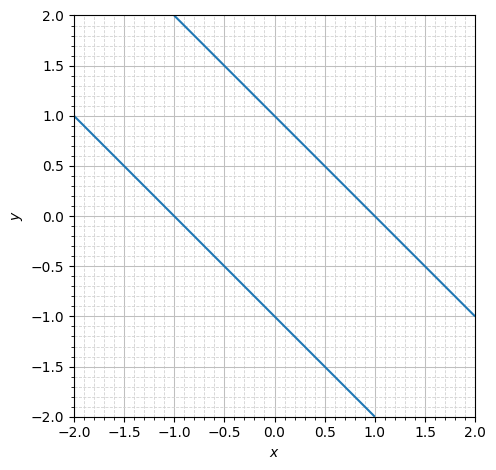

In [8]:
graphics(
    implicit_2d(eq_matrix.subs(quad_subs), (x, -2, 2), (y, -2, 2)),
    aspect='equal'
)

In [9]:
Eq(quad_eq, *matrix_eq).subs(quad_subs | {x: .5, y: .5})

True

In [10]:
P = Matrix([[0, -1], [1, 0]])
P

Matrix([
[0, -1],
[1,  0]])

In [11]:
A

Matrix([
[a, b],
[b, c]])

In [12]:
A_similar = P.T * A * P
A_similar

Matrix([
[ c, -b],
[-b,  a]])

In [13]:
Eq(A, P.T * A_similar * P)

True

In [14]:
lamb, mu, x_p, y_p = symbols('λ, μ, x, y')

eq1 = Eq(lamb * x_p**2 + mu * y_p**2, 1)
eq1

Eq(x**2*λ + y**2*μ, 1)

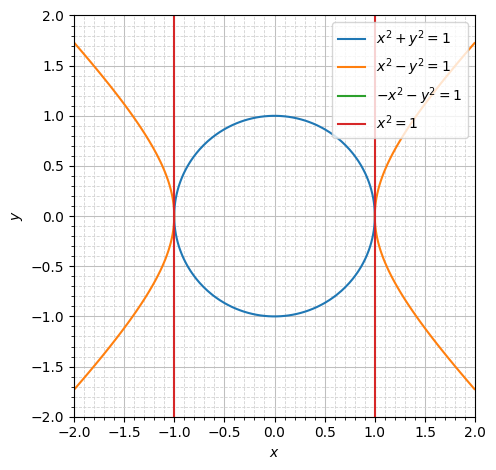

In [15]:
graphics(
    implicit_2d(eq1.subs({lamb: 1, mu: 1}), (x_p, -2, 2), (y_p, -2, 2)),
    implicit_2d(eq1.subs({lamb: 1, mu: -1}), (x_p, -2, 2), (y_p, -2, 2)),
    implicit_2d(eq1.subs({lamb: -1, mu: -1}), (x_p, -2, 2), (y_p, -2, 2)),
    implicit_2d(eq1.subs({lamb: 1, mu: 0}), (x_p, -2, 2), (y_p, -2, 2)),
    aspect='equal'
)

<lambdifygenerated-17>:2: RuntimeWarning: invalid value encountered in power


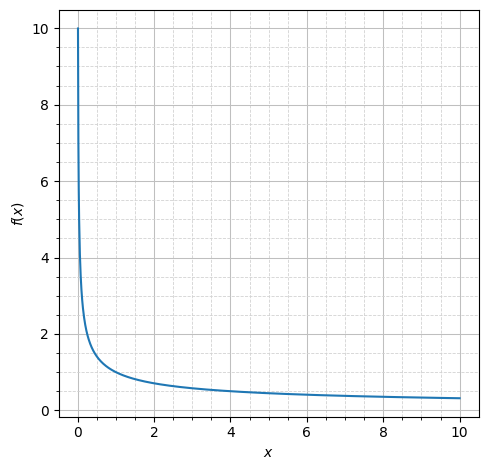

In [16]:
graphics(
    line(x**(-1/2), (x, 0, 10)),
    aspect='equal'
)

In [17]:
idt = eye(2)
idt

Matrix([
[1, 0],
[0, 1]])

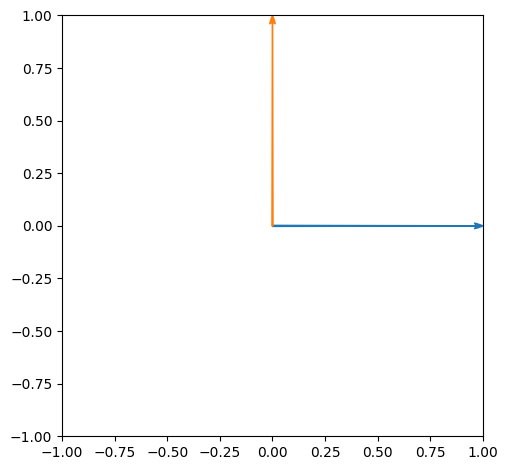

In [18]:
def matrix_to_vec(M, ij):
    i = tuple([x for y in M[:, ij].tolist() for x in y])
    return (0, 0), i

graphics(
    arrow_2d(*matrix_to_vec(idt, 0)),
    arrow_2d(*matrix_to_vec(idt, 1)),
    xlim=(-1, 1),
    ylim=(-1, 1),
    aspect='equal',
    legend=False,
    grid=False
)

In [19]:
m = Matrix([[0, -1], [-1, 0]])
m

Matrix([
[ 0, -1],
[-1,  0]])

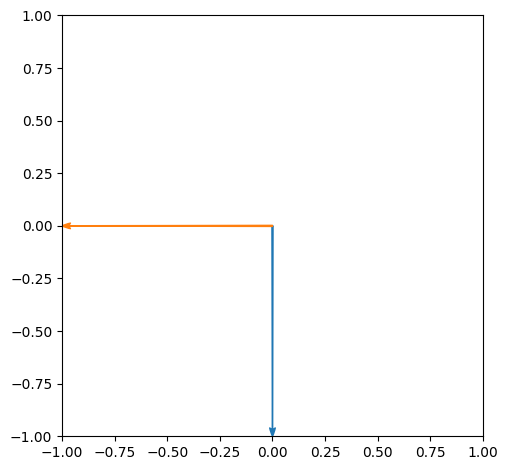

In [20]:
graphics(
    arrow_2d(*matrix_to_vec(m, 0)),
    arrow_2d(*matrix_to_vec(m, 1)),
    xlim=(-1, 1),
    ylim=(-1, 1),
    aspect='equal',
    legend=False,
    grid=False
)

In [21]:
T = Matrix([[1, 0, 3], [0, 2, 0], [3, 0, 3]])
T

Matrix([
[1, 0, 3],
[0, 2, 0],
[3, 0, 3]])

In [22]:
T_eigenvecs = T.eigenvects()
T_eigenvecs

[(2,
  1,
  [Matrix([
   [0],
   [1],
   [0]])]),
 (2 - sqrt(10),
  1,
  [Matrix([
   [-sqrt(10)/3 - 1/3],
   [                0],
   [                1]])]),
 (2 + sqrt(10),
  1,
  [Matrix([
   [-1/3 + sqrt(10)/3],
   [                0],
   [                1]])])]

In [23]:
T_lamb = T_eigenvecs[1][0]
T_lamb

2 - sqrt(10)

In [24]:
T_eigenvector = T_eigenvecs[1][2][0]
T_eigenvector

Matrix([
[-sqrt(10)/3 - 1/3],
[                0],
[                1]])

In [25]:
Eq(T * T_eigenvector, T_lamb * T_eigenvector)

True

In [26]:
T_eigenvector.norm()

sqrt(1 + (1/3 + sqrt(10)/3)**2)

In [27]:
T_eigenvector.norm().n()

1.71024869277790

In [28]:
T_eigen_normal = T_eigenvector.normalized()
T_eigen_normal

Matrix([
[(-sqrt(10)/3 - 1/3)/sqrt(1 + (1/3 + sqrt(10)/3)**2)],
[                                                  0],
[                  1/sqrt(1 + (1/3 + sqrt(10)/3)**2)]])

In [29]:
T_eigen_normal.norm()

sqrt(1/(1 + (1/3 + sqrt(10)/3)**2) + (1/3 + sqrt(10)/3)**2/(1 + (1/3 + sqrt(10)/3)**2))

In [30]:
T_eigen_normal.norm().n()

1.00000000000000

In [31]:
E_orthonormal = Matrix(
    [
        T_eigen_normal.T,
        T_eigenvecs[0][2][0].normalized().T,
        T_eigenvecs[2][2][0].normalized().T
    ]
)

E_orthonormal

Matrix([
[ (-sqrt(10)/3 - 1/3)/sqrt(1 + (1/3 + sqrt(10)/3)**2), 0,  1/sqrt(1 + (1/3 + sqrt(10)/3)**2)],
[                                                   0, 1,                                  0],
[(-1/3 + sqrt(10)/3)/sqrt((-1/3 + sqrt(10)/3)**2 + 1), 0, 1/sqrt((-1/3 + sqrt(10)/3)**2 + 1)]])

In [32]:
B = Symbol('B')

A_trans = Matrix([[T_lamb, 0, 0], [0, B, B], [0, B, B]])
A_trans

Matrix([
[2 - sqrt(10), 0, 0],
[           0, B, B],
[           0, B, B]])

In [33]:
B_matrix = Matrix([[T_eigenvecs[0][0], 0], [0, T_eigenvecs[2][0]]])

A_trans[1:, 1:] = B_matrix
A_trans

Matrix([
[2 - sqrt(10), 0,            0],
[           0, 2,            0],
[           0, 0, 2 + sqrt(10)]])

In [34]:
Eq((E_orthonormal.T * A_trans * E_orthonormal).n(), T)

True

In [35]:
Eq(E_orthonormal.T, E_orthonormal**-1)

True

In [36]:
X = E_orthonormal[:, 0]

eq_l = X.T * A_trans * X
eq_l

Matrix([[(2 - sqrt(10))*(-sqrt(10)/3 - 1/3)**2/(1 + (1/3 + sqrt(10)/3)**2) + (-1/3 + sqrt(10)/3)**2*(2 + sqrt(10))/((-1/3 + sqrt(10)/3)**2 + 1)]])

In [37]:
i = Idx('i')
j = Idx('j')

n = shape(E_orthonormal)[0]

a_trans = MatrixSymbol('a', n, n)
x_sym = IndexedBase('x')

eq_r = Sum(x_sym[i] * a_trans[i, j] * x_sym[j], (i, 0, n-1), (j, 0, n-1))
eq_r

Sum(x[i]*x[j]*a[i, j], (i, 0, 2), (j, 0, 2))

In [38]:
eq_r_subs = eq_r.subs({x_sym: X, a_trans: A_trans}).doit()
eq_r_subs

(2 - sqrt(10))*(-sqrt(10)/3 - 1/3)**2/(1 + (1/3 + sqrt(10)/3)**2) + (-1/3 + sqrt(10)/3)**2*(2 + sqrt(10))/((-1/3 + sqrt(10)/3)**2 + 1)

In [39]:
Eq(eq_l[0], eq_r_subs)

True

In [40]:
T_E_E = Matrix([[2, 0], [0, 2]])
T_E_E

Matrix([
[2, 0],
[0, 2]])

In [41]:
E_lamb = Matrix([m[:] for m in T_E_E.eigenvects()[0][2]])
E_lamb

Matrix([
[1, 0],
[0, 1]])

In [42]:
lamb_multiplicity = list(T_E_E.eigenvals())[0]
lamb_multiplicity

2

In [43]:
Eq(shape(E_lamb)[0], lamb_multiplicity)

True

In [44]:
E_lamb.charpoly()

PurePoly(lambda**2 - 2*lambda + 1, lambda, domain='ZZ')

In [45]:
E_lamb_roots = E_lamb.charpoly().all_roots()
E_lamb_roots

[1, 1]

In [46]:
Eq(lamb_multiplicity, dict(Counter(E_lamb_roots))[1])

True

In [47]:
v = Matrix([1, 2])
v

Matrix([
[1],
[2]])

In [48]:
sum_v_lamb = [sum(i) for i in zip(*[tuple(E_lamb.col(x)) for x in (0, 1)])]
sum_v_lamb

[1, 1]